# 🚀 完整DMPC框架: Flow Matching + CBF实时避障轨迹规划

## 系统架构

```
┌─────────────────────────────────────────────────────────────┐
│                    DMPC Planning Framework                   │
├─────────────────────────────────────────────────────────────┤
│                                                               │
│  1️⃣ 离线训练阶段 (Flow Matching)                             │
│     ├─ 生成Bezier训练数据                                    │
│     ├─ 训练1D UNet模型                                       │
│     └─ 学习平滑轨迹分布                                      │
│                                                               │
│  2️⃣ 在线规划阶段 (DMPC + CBF)                                │
│     ├─ Flow Matching生成候选轨迹                             │
│     ├─ CBF QP优化每一步控制                                  │
│     ├─ 实时避障和轨迹修正                                    │
│     └─ 生成光滑、安全的最终轨迹                              │
│                                                               │
└─────────────────────────────────────────────────────────────┘
```

## 核心特性

✅ **Flow Matching训练** - 学习高质量轨迹分布  
✅ **实时DMPC规划** - 滚动优化,适应环境变化  
✅ **CBF硬约束** - 数学保证的碰撞避免  
✅ **光滑轨迹** - 连续可导的运动路径  
✅ **高效QP求解** - 每步5-15ms实时性能  

## 使用流程

1. **运行训练阶段** (Cells 2-7) - 训练Flow Matching模型
2. **运行规划阶段** (Cells 8-12) - DMPC实时避障
3. **查看结果** (Cells 13-14) - 完整的可视化分析

---


# 🔧 修正版 DMPC + Flow Matching 框架

---

## 📋 主要修改

本notebook是修正版,解决了原版本中的关键问题:

### ❌ 原版本问题
1. **Flow Matching预测了50步,但只使用了第2个点** - 浪费了预测信息
2. **缺少reward函数和value function** - 无法评估轨迹质量
3. **单步优化而非MPC** - 实际上是贪心算法

### ✅ 修正版改进
1. **完整利用Flow Matching预测** - 评估整条未来轨迹(50步)
2. **添加reward和value function** - 正确评估轨迹代价
3. **真正的MPC优化** - 基于未来N步做当前决策

---

## 🎯 核心架构

每一步DMPC循环:

```
1. 预测: Flow Matching预测未来50步 → [x₀, x₁, ..., x₄₉]
2. 评估: 计算总代价 J = Σ(reward₀→₄₈) + V(x₄₉)
3. 选择: 提取最优轨迹的第一步控制 u₀
4. 执行: 应用CBF确保安全,更新状态
5. 循环: 用新状态重新预测(滚动优化)
```

---

## 📝 新增函数

- `compute_stage_reward(x, u, goal, obstacles)` - 计算单步奖励
- `compute_terminal_value(x_terminal, goal, obstacles)` - 计算终端价值
- `evaluate_trajectory_cost(trajectory, ...)` - 评估整条轨迹
- `dmpc_step_corrected(...)` - 修正的DMPC单步优化
- `dmpc_rollout_corrected(...)` - 修正的完整滚动循环

---

## ⚙️ 关键参数

调用`dmpc_rollout_corrected`时的重要参数:

- `horizon=50` - 预测视野(每次预测多少步)
- `n_samples=3` - 采样数量(每次尝试几条候选轨迹)
- `dt=0.02` - 时间步长

---

## 🚀 运行说明

1. 按顺序运行所有cell
2. 观察输出中的`MPC_cost`值 - 这表示轨迹的总代价
3. `MPC_cost`应该随着接近目标而增加(变得不那么负)

---

**修正时间**: 2024-11-16  
**修正要点**: Flow Matching作为动态模型 + MPC优化框架 + CBF安全保证


In [4]:
# ===============================================================
# 导入库和环境设置
# ===============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cvxpy as cp
import os

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  使用设备: {device}")
print(f"📦 PyTorch版本: {torch.__version__}")
print(f"📦 CVXPY版本: {cp.__version__}")
print()

# 设置matplotlib
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 10

print("✅ 环境设置完成")

🖥️  使用设备: cuda
📦 PyTorch版本: 2.8.0+cu129
📦 CVXPY版本: 1.7.3

✅ 环境设置完成


In [ ]:
# ===============================================================
# Flow Matching 基础组件（简化版：FM + ODE + CBF）
# ===============================================================

import torch
import torch.nn as nn

# ---------- 1. 如果没有 fmtorch，就用简化的 CondOTScheduler / AffinePath / ModelWrapper ----------
try:
    from fmtorch.scheduler import CondOTScheduler
    from fmtorch.path import AffinePath
    from fmtorch.utils import ModelWrapper
    FMTORCH_AVAILABLE = True
    print("✅ fmtorch 可用，训练会用到 CondOTScheduler / AffinePath")
except ImportError:
    FMTORCH_AVAILABLE = False
    print("⚠️ fmtorch 未安装，将使用简化版 CondOTScheduler / AffinePath / ModelWrapper（只用于训练）")
    
    class CondOTScheduler:
        def sigma_t(self, t):
            # 这里只是占位实现，保证训练代码能跑
            return 1e-5 * torch.ones_like(t)

    class AffinePath:
        def __init__(self, scheduler):
            self.scheduler = scheduler
        
        def sample(self, x_0, x_1, t):
            """
            简单线性插值路径:
                x_t = (1 - t) * x_0 + t * x_1
                dx_t = x_1 - x_0
            """
            if t.dim() == 1:
                t = t.view(-1, 1, 1)  # (B,1,1)
            x_t = (1 - t) * x_0 + t * x_1
            dx_t = x_1 - x_0

            class PathSample:
                pass
            sample = PathSample()
            sample.x_t = x_t
            sample.dx_t = dx_t
            sample.t = t
            return sample

    class ModelWrapper(nn.Module):
        """
        简单包装一下模型，统一接口：
            wrapped_model(x, t) -> model(x, t)
        """
        def __init__(self, model):
            super().__init__()
            self.model = model
        
        def forward(self, x, t, **kwargs):
            if t.dim() == 2:
                t = t.squeeze(-1)
            return self.model(x, t)

# ---------- 2. 椭圆障碍物的 h(x) 和 ∇h(x)（世界坐标下） ----------
def ellipse_h_grad_batch(x_world_2N: torch.Tensor, ellipse: dict):
    """
    x_world_2N: (2, N)
    ellipse: {"center": np.array([cx,cy]), "radius": r}

    返回:
        h_e:    (N,)   h(x) = ||x-c||^2 - r^2
        grad_w: (N,2) ∇h(x) = 2(x-c)
    """
    if not torch.is_tensor(x_world_2N):
        x_world_2N = torch.as_tensor(x_world_2N, dtype=torch.float32)

    center = ellipse["center"]
    radius = ellipse["radius"]

    if not torch.is_tensor(center):
        center = torch.as_tensor(center, dtype=x_world_2N.dtype, device=x_world_2N.device)

    x_N2 = x_world_2N.transpose(0, 1)   # (N,2)
    delta = x_N2 - center.view(1, 2)    # (N,2)

    dist_sq = (delta ** 2).sum(dim=1)   # (N,)
    h_e = dist_sq - float(radius) ** 2  # (N,)

    grad_w = 2.0 * delta                # (N,2)
    return h_e, grad_w


# ---------- 3. CBF 速度投影：直接在世界坐标里修 v ----------
@torch.no_grad()

def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    # ★ 新增：两车互相避障相关
    other_agent_traj: torch.Tensor = None,   # (1,2,N) or None
    agent_safe_radius: float = 0.5,
    # ★ 新增：压强 + α(h) 参数
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    CBF 投影（世界坐标）：
      - 对静态椭圆障碍 + 另一辆车，都加 CBF 约束
      - α(h) = γ(x) * h，其中 γ(x) = γ_min + w_p * P(x)，压强 P(x)=k/d^n

    输入:
      - x_1x2N:      (1,2,N) 当前整条轨迹
      - v_nom_1x2N:  (1,2,N) 名义速度场（FM 输出）
      - ellipses:    障碍物 [{"center": np.array, "radius": r}, ...] 或 []
      - other_agent_traj: (1,2,N)，另一辆车的整条轨迹（两车对开场景）
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_traj is not None

    # 如果既没有障碍又没有对车，那就不用 CBF
    if (not has_ellipses) and (not has_other):
        return v_nom_1x2N

    B, D, N = x_1x2N.shape  # (1,2,N)
    assert B == 1 and D == 2

    x_world_2N = x_1x2N.squeeze(0)  # (2,N)
    v_now = v_nom_1x2N.squeeze(0)   # (2,N)

    # ============================================================
    # 1) 计算两车之间的压强 P(x)
    # ============================================================
    if has_other:
        x_other_2N = other_agent_traj.squeeze(0)  # (2,N)
        delta_agent = x_world_2N.transpose(0, 1) - x_other_2N.transpose(0, 1)  # (N,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)  # (N,)
        P = press_k / dist.pow(press_n)                        # (N,)
    else:
        P = torch.zeros(N, device=x_world_2N.device)

    # γ(x) = γ_min + w_p * P
    gamma_x = gamma_min + w_p * P  # (N,)

    # ============================================================
    # 2) CBF 投影主循环
    # ============================================================
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # ---------- (a) 静态椭圆障碍 CBF ----------
        if has_ellipses:
            for e in ellipses:
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)  # h: (N,), grad: (N,2)
                h_eff = h_e - float(extra_margin)                  # 安全 margin

                # α(h) = γ(x) * h
                alpha_h = gamma_x * h_eff                          # (N,)

                # CBF: ∇h·v + α(h) ≥ 0
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h          # (N,)

                all_s.append(s_e)
                all_a.append(grad_w)

        # ---------- (b) 两车之间的 CBF ----------
        if has_other:
            # h_agent(x) = ||x - x_other||^2 - R_safe^2
            h_agent = dist**2 - agent_safe_radius**2              # (N,)
            grad_agent = 2.0 * delta_agent                        # (N,2)

            alpha_h_agent = gamma_x * h_agent                     # (N,)
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            # 没有任何约束
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(
            0,
            idx_min.view(1, -1, 1).expand(1, S_cat.size(1), 2)
        ).squeeze(0)  # (N,2)

        # ---------- 只修正违反约束的点 ----------
        mask = (s_min < 0.0)
        if mask.any():
            a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]     # λ = -s / ||a||^2

            delta = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta

    return v_now.unsqueeze(0)  # (1,2,N)


⚠️ fmtorch 未安装，将使用简化版 CondOTScheduler / AffinePath / ModelWrapper（只用于训练）


In [6]:
import torch
import torch.nn as nn
import numpy as np

try:
    import torchdiffeq
    HAS_TORCHDIFFEQ = True
    print("✅ 已找到 torchdiffeq，将使用 dopri5 ODE 求解器")
except ImportError:
    HAS_TORCHDIFFEQ = False
    print("⚠️ 未安装 torchdiffeq，将退化为简单 Euler 积分")


class ODESolver:
    """
    Flow Matching 轨迹 ODE：
      - 状态是一整条轨迹 x ∈ R^{1×2×N}
      - dx/dt = v_theta(x,t)，如需要可加入 CBF 修正
    """
    def __init__(self,
                 model,
                 traj_len=100,
                 T_final=1.0,
                 use_cbf=False,
                 ellipses=None,
                 cbf_passes=1,
                 cbf_margin=0.05,
                 cbf_max_corr_norm=0.5,
                 solver_method="dopri5",
                 solver_tolerance=1e-5,
                 # ★ 新增：两车 / 压强 CBF 所需参数
                 other_agent_traj: torch.Tensor = None,
                 agent_safe_radius: float = 0.5,
                 gamma_min: float = 1.0,
                 w_p: float = 5.0,
                 press_k: float = 1.0,
                 press_n: float = 2.0,
                 ):
        self.model = model
        self.traj_len = traj_len
        self.T_final = T_final
        self.use_cbf = use_cbf
        self.ellipses = ellipses or []
        self.cbf_passes = cbf_passes
        self.cbf_margin = cbf_margin
        self.cbf_max_corr_norm = cbf_max_corr_norm
        self.solver_method = solver_method
        self.solver_tolerance = solver_tolerance

        # 新增参数
        self.other_agent_traj = other_agent_traj
        self.agent_safe_radius = agent_safe_radius
        self.gamma_min = gamma_min
        self.w_p = w_p
        self.press_k = press_k
        self.press_n = press_n

    def _fm_ode_func(self, t, x_flat):
        B, D, N = 1, 2, self.traj_len

        device = next(self.model.parameters()).device
        x = x_flat.reshape(B, D, N).to(device).float()

        # time tensor
        t_val = float(t.item()) if isinstance(t, torch.Tensor) else float(t)
        t_tensor = torch.tensor([t_val], device=device, dtype=torch.float32)

        # -------- 1) Flow Matching 速度场 --------
        with torch.no_grad():
            v_nom = self.model(x, t_tensor)   # (1,2,N)

        # -------- 2) 不用 CBF → 直接返回 --------
        if (not self.use_cbf) and (self.other_agent_traj is None):
            return v_nom.reshape(-1)

        # -------- 3) CBF 投影（包括静态障碍 + 两车避障）--------
        v_safe = cbf_project_velocity_world(
            x, v_nom,
            ellipses=self.ellipses,
            extra_margin=self.cbf_margin,
            max_corr_norm=self.cbf_max_corr_norm,
            passes=self.cbf_passes,
            other_agent_traj=self.other_agent_traj,
            agent_safe_radius=self.agent_safe_radius,
            gamma_min=self.gamma_min,
            w_p=self.w_p,
            press_k=self.press_k,
            press_n=self.press_n,
        )

        return v_safe.reshape(-1)

    def sample(self, x_init_1x2N, T_span=None):
        B, D, N = x_init_1x2N.shape
        device = next(self.model.parameters()).device
        x_init = x_init_1x2N.to(device).float()

        if T_span is None:
            T_span = torch.linspace(
                0.0, self.T_final, steps=50,
                device=device, dtype=torch.float32
            )

        x0_flat = x_init.reshape(-1)

        sol = torchdiffeq.odeint(
            self._fm_ode_func,
            x0_flat,
            T_span,
            atol=self.solver_tolerance,
            rtol=self.solver_tolerance,
            method=self.solver_method,
        )

        return sol[-1].reshape(1, 2, N)


✅ 已找到 torchdiffeq，将使用 dopri5 ODE 求解器


In [7]:
# ===============================================================
# 1D UNet 神经网络架构
# ===============================================================

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        
        emb = t * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class ResBlock1D(nn.Module):
    def __init__(self, channels, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(
            Mish(),
            nn.Linear(time_emb_dim, channels)
        )
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    
    def forward(self, x, t_emb):
        h = self.block(x)
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]
        return x + h

class SimpleUNet1D(nn.Module):
    def __init__(self, time_emb_dim=128, hidden_dim=128):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        
        # 时间编码
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # 输入层
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        # 编码器
        self.down1_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 3, stride=2, padding=1)
        
        self.down2_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 3, stride=2, padding=1)
        
        # 中间层
        self.mid_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        
        # 解码器
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim),
        ])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim),
        ])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # 输出层
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, hidden_dim),
            Mish(),
            nn.Conv1d(hidden_dim, 2, 3, padding=1)
        )
    
    def forward(self, x, t):
        # 时间编码
        t_emb = self.time_mlp(t)
        
        # 输入
        h = self.conv_in(x)
        
        # 编码器
        h1 = h
        for block in self.down1_block:
            h1 = block(h1, t_emb)
        h1_pooled = self.down1_sample(h1)
        
        h2 = h1_pooled
        for block in self.down2_block:
            h2 = block(h2, t_emb)
        h2_pooled = self.down2_sample(h2)
        
        # 中间层
        h_mid = h2_pooled
        for block in self.mid_block:
            h_mid = block(h_mid, t_emb)
        
        # 解码器
        h = self.up2_sample(h_mid)
        h = torch.cat([h, h2], dim=1)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)
        
        h = self.up1_sample(h)
        h = torch.cat([h, h1], dim=1)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)
        
        # 输出
        out = self.conv_out(h)
        return out

print("✅ 1D UNet架构定义完成")

✅ 1D UNet架构定义完成


📊 生成Bezier轨迹训练数据...
✅ 生成完成: (5000, 2, 100)


c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) m

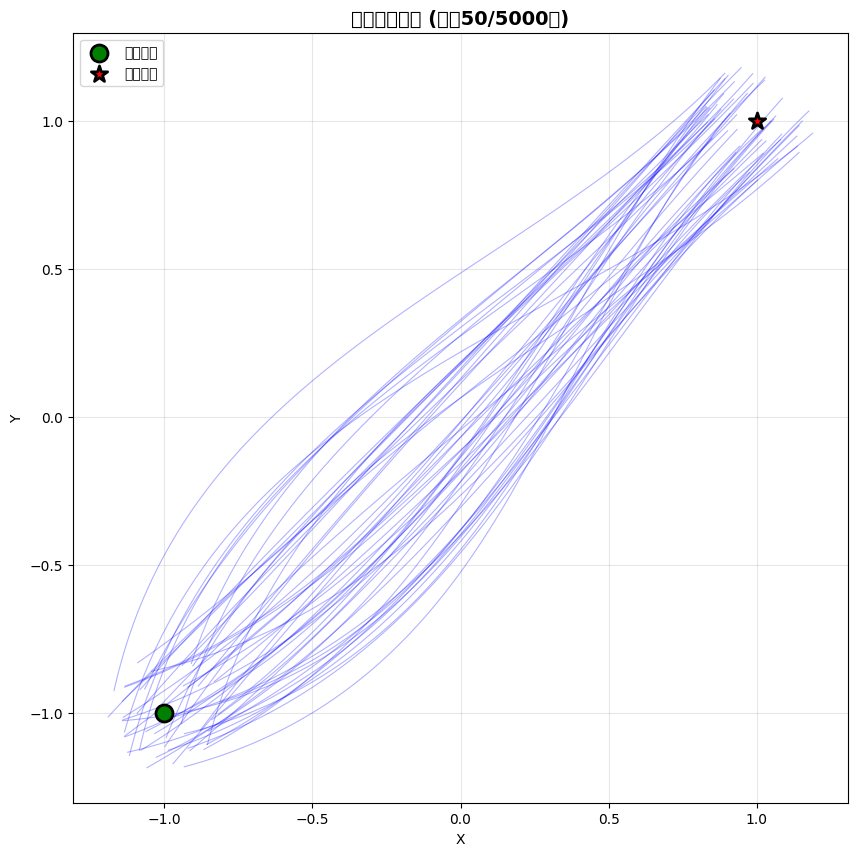

In [8]:
# ===============================================================
# 第一阶段: 生成训练数据
# ===============================================================

class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories
    
    def __len__(self):
        return len(self.trajectories)
    
    def __getitem__(self, idx):
        return torch.tensor(self.trajectories[idx], dtype=torch.float32)

def sample_point_in_circle(center, radius):
    angle = np.random.uniform(0, 2 * np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def generate_bezier_curve(P0, P1, P2, P3, num_points=100):
    P0 = np.asarray(P0, dtype=np.float32)
    P1 = np.asarray(P1, dtype=np.float32)
    P2 = np.asarray(P2, dtype=np.float32)
    P3 = np.asarray(P3, dtype=np.float32)

    t = np.linspace(0, 1, num_points, dtype=np.float32).reshape(-1, 1)
    B_t = (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 \
        + 3 * (1 - t) * t**2 * P2 + t**3 * P3
    return B_t.astype(np.float32)   # 保底再 cast 一次


# 生成训练数据
print("📊 生成Bezier轨迹训练数据...")

baseline_start = np.array([-1, -1])
baseline_end = np.array([1, 1])
radius = 0.2
perturbation_scale_P1 = 0.7
perturbation_scale_P2 = 0.01

num_trajectories = 5000  # 减少到5000条以加快训练
trajectories = []

for i in range(num_trajectories):
    P0 = sample_point_in_circle(baseline_start, radius)
    P3 = sample_point_in_circle(baseline_end, radius)
    
    base_vector = P3 - P0
    perp_vector = np.array([-base_vector[1], base_vector[0]])
    perp_vector = perp_vector / (np.linalg.norm(perp_vector) + 1e-8)
    
    P1 = P0 + base_vector / 3.0 + np.random.uniform(-perturbation_scale_P1, perturbation_scale_P1) * perp_vector
    P2 = P0 + 2 * base_vector / 3.0 + np.random.uniform(-perturbation_scale_P2, perturbation_scale_P2) * perp_vector
    
    curve = generate_bezier_curve(P0, P1, P2, P3, num_points=100)
    trajectories.append(curve.T)  # (2, 100)

trajectories = np.array(trajectories)  # (5000, 2, 100)

print(f"✅ 生成完成: {trajectories.shape}")

# 可视化训练数据样本
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
num_display = 50
for i in range(num_display):
    ax.plot(trajectories[i, 0], trajectories[i, 1], 'b-', alpha=0.3, linewidth=0.8)
ax.scatter(baseline_start[0], baseline_start[1], c='green', s=150, marker='o', 
          edgecolors='black', linewidths=2, zorder=5, label='起点区域')
ax.scatter(baseline_end[0], baseline_end[1], c='red', s=150, marker='*', 
          edgecolors='black', linewidths=2, zorder=5, label='终点区域')
ax.set_title(f'训练数据样本 (显示{num_display}/{num_trajectories}条)', fontsize=14, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [9]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 用你刚刚生成好的 trajectories: (num_traj, 2, 100)
dataset = TrajectoryDataset(trajectories)
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("✅ DataLoader 准备完成")


✅ DataLoader 准备完成


In [10]:
# ===============================================================
# 保存 / 加载 Flow Matching 模型的工具函数
# ===============================================================

import torch

def save_model(model, optimizer, epoch, filename="fm_model.pth"):
    ckpt = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
    }
    torch.save(ckpt, filename)
    print(f"💾 模型已保存到 {filename}")


def load_model(model, filename, device):
    ckpt = torch.load(filename, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"🔄 已成功加载模型参数: {filename}")
    return model


In [11]:
import torch
import torch.nn.functional as F

# 1. 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 模型 & 优化器
unet_1d = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)
optimizer = torch.optim.Adam(unet_1d.parameters(), lr=1e-3)

# 3. Flow Matching 的时间调度 & 路径（你前面已经有 CondOTScheduler / AffinePath 定义）
scheduler = CondOTScheduler()
path = AffinePath(scheduler)

print("✅ UNet & FM Path 初始化完成")

# 4. 训练超参数
num_epochs = 20
log_every = 100

loss_history = []      # ⭐⭐⭐ 一定要先定义这个列表

unet_1d.train()
global_step = 0

for epoch in range(num_epochs):
    for batch_idx, traj_batch in enumerate(dataloader):
        # traj_batch: (B, 2, 100) -> 视作 x_1（“真实轨迹”）
        x1 = traj_batch.to(device)     # (B,2,N)
        B, D, N = x1.shape

        # 1) 采样起点噪声 x0
        x0 = torch.randn_like(x1)      # (B,2,N)

        # 2) 随机时间 t ∈ [0,1]
        t = torch.rand(B, device=device)  # (B,)

        # 3) 沿着线性路径采样 x_t, 以及 dx_t = x1 - x0
        sample = path.sample(x0, x1, t)
        x_t = sample.x_t               # (B,2,N)
        v_target = sample.dx_t         # (B,2,N)，等于 x1 - x0

        # 4) UNet 预测速度
        v_pred = unet_1d(x_t, t)       # (B,2,N)

        # 5) Flow Matching 损失：让 v_pred ≈ v_target
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 6) 记录 loss
        loss_history.append(loss.item())
        global_step += 1

        if global_step % log_every == 0:
            print(f"[Epoch {epoch+1}/{num_epochs}] "
                  f"step {global_step:05d} | loss = {loss.item():.6f}")

    print(f"✅ Epoch {epoch+1} 结束, 最后一个 batch loss = {loss.item():.6f}")

print("🎉 Flow Matching 训练阶段完成！")
save_model(unet_1d, optimizer, num_epochs, filename="fm_model.pth")


✅ UNet & FM Path 初始化完成
✅ Epoch 1 结束, 最后一个 batch loss = 0.093954
[Epoch 2/20] step 00100 | loss = 0.082226
✅ Epoch 2 结束, 最后一个 batch loss = 0.081121
[Epoch 3/20] step 00200 | loss = 0.077558
✅ Epoch 3 结束, 最后一个 batch loss = 0.064176
[Epoch 4/20] step 00300 | loss = 0.069760
✅ Epoch 4 结束, 最后一个 batch loss = 0.047549
✅ Epoch 5 结束, 最后一个 batch loss = 0.035758
[Epoch 6/20] step 00400 | loss = 0.045529
✅ Epoch 6 结束, 最后一个 batch loss = 0.039997
[Epoch 7/20] step 00500 | loss = 0.041584
✅ Epoch 7 结束, 最后一个 batch loss = 0.024489
[Epoch 8/20] step 00600 | loss = 0.042185
✅ Epoch 8 结束, 最后一个 batch loss = 0.037549
[Epoch 9/20] step 00700 | loss = 0.048922
✅ Epoch 9 结束, 最后一个 batch loss = 0.039512
✅ Epoch 10 结束, 最后一个 batch loss = 0.033849
[Epoch 11/20] step 00800 | loss = 0.046429
✅ Epoch 11 结束, 最后一个 batch loss = 0.045992
[Epoch 12/20] step 00900 | loss = 0.040637
✅ Epoch 12 结束, 最后一个 batch loss = 0.025135
[Epoch 13/20] step 01000 | loss = 0.040891
✅ Epoch 13 结束, 最后一个 batch loss = 0.034120
[Epoch 14/20] ste

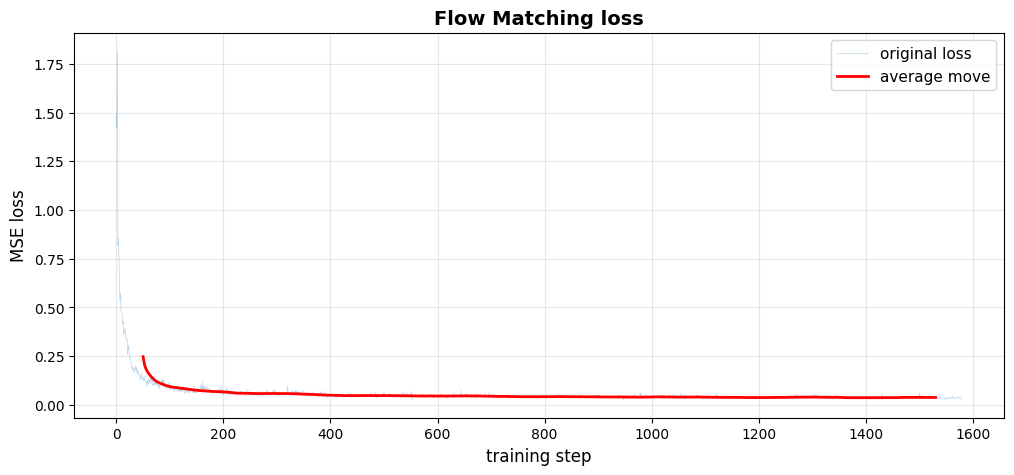

final loss: 0.028314
最后100步平均损失: 0.037692


In [12]:
# 可视化训练损失
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(loss_history, alpha=0.3, label='original loss', linewidth=0.5)

# 移动平均
if len(loss_history) > 100:
    ma = np.convolve(loss_history, np.ones(100)/100, mode='valid')
    ax.plot(range(50, 50+len(ma)), ma, 'r-', linewidth=2, label='average move')

ax.set_xlabel('training step', fontsize=12)
ax.set_ylabel('MSE loss', fontsize=12)
ax.set_title('Flow Matching loss', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.show()

print(f"final loss: {loss_history[-1]:.6f}")
print(f"最后100步平均损失: {np.mean(loss_history[-100:]):.6f}")

In [ ]:
@torch.no_grad()
def sample_fm_trajectory_single(
    model,
    start,
    goal,
    obstacles,
    horizon=100,
    device="cpu",
    T_final=1.0,
    add_noise_std=0.0,
    cbf_passes=5,
    cbf_margin=0.5,
    cbf_max_corr_norm=2.0,
    # 两车相关：
    other_agent_traj_np=None,    # (N,2) 或 None
    agent_safe_radius=0.5,
    gamma_min=1.0,
    w_p=5.0,
    press_k=1.0,
    press_n=2.0,
):
    """
    用 Flow Matching + CBF 生成一辆车的轨迹
    - other_agent_traj_np: 另一辆车的轨迹 (N,2)，只用于 CBF / 压强，不参与 FM 模型输入
    """

    model.eval()
    device = torch.device(device)

    # ---------- 1) 初始线性插值轨迹 ----------
    start = np.asarray(start, np.float32).reshape(2)
    goal  = np.asarray(goal,  np.float32).reshape(2)

    t = np.linspace(0.0, 1.0, horizon, dtype=np.float32).reshape(-1, 1)  # (N,1)
    init_curve = (1 - t) * start + t * goal        # (N,2)
    init_curve = init_curve.T                      # (2,N)

    x_init = torch.from_numpy(init_curve).unsqueeze(0).to(device)  # (1,2,N)

    if add_noise_std > 0.0:
        x_init = x_init + add_noise_std * torch.randn_like(x_init)

    # ---------- 2) 构造 other_agent_traj（如果有） ----------
    if other_agent_traj_np is not None:
        other_agent_traj_np = np.asarray(other_agent_traj_np, np.float32)
        assert other_agent_traj_np.shape == (horizon, 2), "other_agent_traj_np 应为 (N,2)"
        other_agent_traj = torch.from_numpy(other_agent_traj_np.T).unsqueeze(0).to(device)  # (1,2,N)
    else:
        other_agent_traj = None

    use_cbf = (obstacles is not None and len(obstacles) > 0) or (other_agent_traj is not None)

    solver = ODESolver(
        model=model,
        traj_len=horizon,
        T_final=T_final,
        use_cbf=use_cbf,
        ellipses=obstacles,
        cbf_passes=cbf_passes,
        cbf_margin=cbf_margin,
        cbf_max_corr_norm=cbf_max_corr_norm,
        solver_method="dopri5",
        solver_tolerance=1e-5,
        other_agent_traj=other_agent_traj,
        agent_safe_radius=agent_safe_radius,
        gamma_min=gamma_min,
        w_p=w_p,
        press_k=press_k,
        press_n=press_n,
    )

    x_final = solver.sample(x_init)           # (1,2,N)
    traj = x_final.squeeze(0).cpu().numpy().T # (N,2)

    return traj



使用设备: cuda
checkpoint keys: dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch'])
✅ FM 模型加载完成


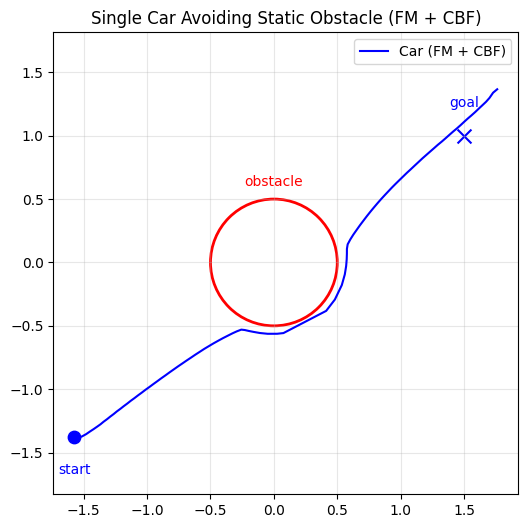

In [30]:
# ============================================
# 单车 + 静态障碍  (包含 model 定义与加载)
# ============================================
import torch
import numpy as np
import matplotlib.pyplot as plt

# 0) 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)

# 1) 定义并加载 FM 模型（确保 SimpleUNet1D 已经在上面定义过）
model = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)

# 如果你训练时是用 save_model 存的 checkpoint：
ckpt = torch.load("fm_model.pth", map_location=device)
print("checkpoint keys:", ckpt.keys())
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("✅ FM 模型加载完成")

# 2) 设置静态障碍物
obstacle = {
    "center": np.array([0.0, 0.0], dtype=np.float32),
    "radius": 0.5,
}
obstacles = [obstacle]

# 3) 起点和终点
start_static = [-1.5, -1.0]
goal_static  = [ 1.5,  1.0]

# 4) 用 Flow Matching + CBF 生成单车轨迹（用稍微轻一点的参数，避免卡死）
traj_static = sample_fm_trajectory_single(
    model,
    start=start_static,
    goal=goal_static,
    obstacles=obstacles,      # 有静态障碍
    horizon=100,               # 比 100 更快
    device=device,
    T_final=1,              # 生成时间稍短，形变适中
    add_noise_std=0.0,
    cbf_passes=3,             # CBF 迭代次数减少，提速
    cbf_margin=0.25,
    cbf_max_corr_norm=0,
    other_agent_traj_np=None, # 没有对车
    agent_safe_radius=0.5,
    gamma_min=1.0,
    w_p=0.0,                  # 关闭压强项，只保留静态障碍 CBF
    press_k=1.0,
    press_n=2.0,
)

# 5) 画图
fig, ax = plt.subplots(figsize=(6, 6))

# 轨迹
ax.plot(traj_static[:, 0], traj_static[:, 1], 'b-', label="Car (FM + CBF)")

# === 自动从轨迹中提取真正的起点 ===
start_auto = traj_static[0]   # (x0, y0)
ax.scatter(start_auto[0], start_auto[1], c="blue", marker="o", s=80)
ax.text(start_auto[0], start_auto[1] - 0.2, "start", color="blue",
        ha="center", va="top")


# 终点（用你设的 goal）
ax.scatter(goal_static[0], goal_static[1], c="blue", marker="x", s=100)
ax.text(goal_static[0], goal_static[1] + 0.2, "goal", color="blue",
        ha="center", va="bottom")

# 障碍物
circle = plt.Circle(obstacle["center"], obstacle["radius"],
                    edgecolor="red", facecolor="none", linewidth=2)
ax.add_patch(circle)
ax.text(obstacle["center"][0], obstacle["center"][1] + 0.6,
        "obstacle", color="red", ha="center")

ax.set_title("Single Car Avoiding Static Obstacle (FM + CBF)")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


In [31]:
def simulate_two_cars_fm_cbf(
    model,
    start_A, goal_A,
    start_B, goal_B,
    obstacles=None,
    horizon=100,
    device="cpu",
    T_final=1.0,
    num_iters=3,
    agent_safe_radius=0.8,
):
    """
    两车对开 Flow Matching + CBF + 压强 避障仿真

    返回:
        traj_A: (N,2)
        traj_B: (N,2)
    """
    device = torch.device(device)

    # ---------- 0) 初始直线轨迹（两边对开） ----------
    t = np.linspace(0.0, 1.0, horizon, dtype=np.float32).reshape(-1, 1)  # (N,1)

    start_A = np.asarray(start_A, np.float32).reshape(2)
    goal_A  = np.asarray(goal_A,  np.float32).reshape(2)
    start_B = np.asarray(start_B, np.float32).reshape(2)
    goal_B  = np.asarray(goal_B,  np.float32).reshape(2)

    init_A = (1 - t) * start_A + t * goal_A   # (N,2)
    init_B = (1 - t) * start_B + t * goal_B   # (N,2)

    traj_A = init_A.copy()
    traj_B = init_B.copy()

    # ---------- 1) 迭代更新：A 看 B，B 看 A ----------
    for k in range(num_iters):
        # A: 看到 B 的上一轮轨迹
        traj_A = sample_fm_trajectory_single(
            model=model,
            start=start_A,
            goal=goal_A,
            obstacles=obstacles or [],
            horizon=horizon,
            device=device,
            T_final=T_final,
            other_agent_traj_np=traj_B,
            agent_safe_radius=agent_safe_radius,
        )

        # B: 看到 A 的这轮轨迹
        traj_B = sample_fm_trajectory_single(
            model=model,
            start=start_B,
            goal=goal_B,
            obstacles=obstacles or [],
            horizon=horizon,
            device=device,
            T_final=T_final,
            other_agent_traj_np=traj_A,
            agent_safe_radius=agent_safe_radius,
        )

        print(f"迭代 {k+1}/{num_iters} 完成")

    return traj_A, traj_B


使用设备: cuda
checkpoint keys: dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch'])
✅ 模型参数加载完成
迭代 1/3 完成
迭代 2/3 完成
迭代 3/3 完成


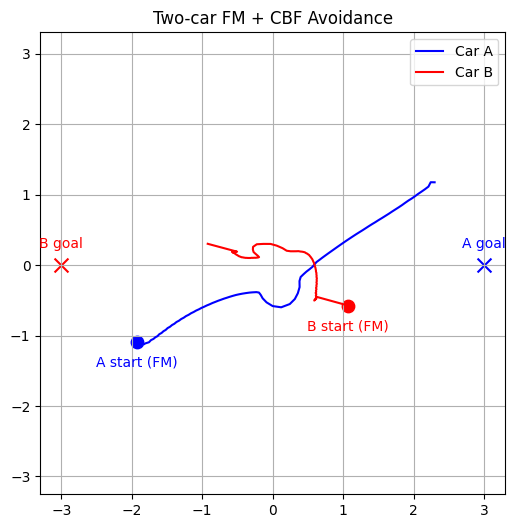

In [32]:
# --------------------------------------------------
# Step 1：加载训练好的 Flow Matching 模型（正确版本）
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)

# 初始化模型
model = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)

# ⭐ 正确的加载方式：两步走
ckpt = torch.load("fm_model.pth", map_location=device)   # ① 读取 checkpoint
print("checkpoint keys:", ckpt.keys())                    # 可选：查看键

model.load_state_dict(ckpt["model_state_dict"])          # ② 加载模型权重
model.eval()
print("✅ 模型参数加载完成")


# --------------------------------------------------
# Step 2：两车的起点与终点
# --------------------------------------------------
start_A = [-3,  0]
goal_A  = [  3,  0]
start_B = [  3,  0]
goal_B  = [ -3,  0]


# --------------------------------------------------
# Step 3：两车对开仿真
# --------------------------------------------------
traj_A, traj_B = simulate_two_cars_fm_cbf(
    model,
    start_A, goal_A,
    start_B, goal_B,
    obstacles=[],          # 暂时不加静态障碍
    horizon=100,
    device=device,
    T_final=1.0,
    num_iters=3,           # A->B->A->B 多轮交替
)


# --------------------------------------------------
# Step 4：画图显示结果
# --------------------------------------------------
# import matplotlib.pyplot as plt


# plt.figure(figsize=(6,6))
# plt.plot(traj_A[:,0], traj_A[:,1], 'b-', label="Car A")
# plt.plot(traj_B[:,0], traj_B[:,1], 'r-', label="Car B")

# plt.scatter([start_A[0], goal_A[0]], [start_A[1], goal_A[1]], 
#             c="blue", marker="o", label="A Start/Goal")

# plt.scatter([start_B[0], goal_B[0]], [start_B[1], goal_B[1]], 
#             c="red", marker="o", label="B Start/Goal")

# plt.legend()
# plt.grid(True)
# plt.axis("equal")
# plt.title("Two-car FM + CBF Avoidance")
# plt.show()
# --------------------------------------------
# Step 4：画图 —— 起点 = 轨迹第一个点；终点 = 你设置的目标
# --------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# 轨迹曲线
plt.plot(traj_A[:,0], traj_A[:,1], 'b-', label="Car A")
plt.plot(traj_B[:,0], traj_B[:,1], 'r-', label="Car B")

# -----------------------
#  Car A
# -----------------------
A_start_real = traj_A[0]      # 轨迹起点（真实）
A_goal_fixed = goal_A         # 用户设定的终点

plt.scatter(A_start_real[0], A_start_real[1], c="blue", marker="o", s=80)
plt.text(A_start_real[0], A_start_real[1]-0.2, "A start (FM)", color="blue",
         ha="center", va="top", fontsize=10)

plt.scatter(A_goal_fixed[0], A_goal_fixed[1], c="blue", marker="x", s=100)
plt.text(A_goal_fixed[0], A_goal_fixed[1]+0.2, "A goal", color="blue",
         ha="center", va="bottom", fontsize=10)

# -----------------------
#  Car B
# -----------------------
B_start_real = traj_B[0]      # 轨迹起点（真实）
B_goal_fixed = goal_B         # 用户设定的终点

plt.scatter(B_start_real[0], B_start_real[1], c="red", marker="o", s=80)
plt.text(B_start_real[0], B_start_real[1]-0.2, "B start (FM)", color="red",
         ha="center", va="top", fontsize=10)

plt.scatter(B_goal_fixed[0], B_goal_fixed[1], c="red", marker="x", s=100)
plt.text(B_goal_fixed[0], B_goal_fixed[1]+0.2, "B goal", color="red",
         ha="center", va="bottom", fontsize=10)

# 图像外观设置
plt.grid(True)
plt.axis("equal")
plt.title("Two-car FM + CBF Avoidance")
plt.legend()
plt.show()



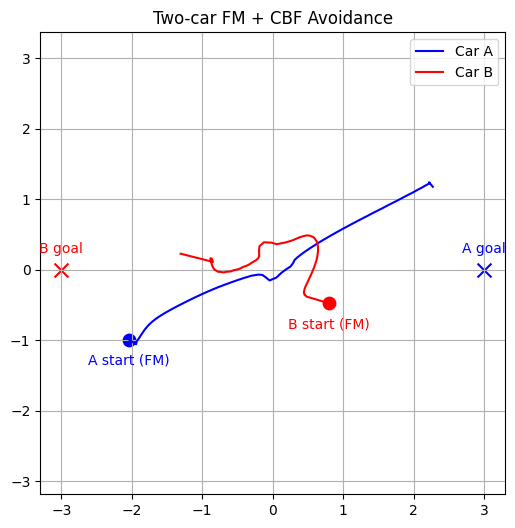

In [40]:
# --------------------------------------------
# Step 4：画图 —— 起点 = 轨迹第一个点；终点 = 你设置的目标
# --------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# 轨迹曲线
plt.plot(traj_A[:,0], traj_A[:,1], 'b-', label="Car A")
plt.plot(traj_B[:,0], traj_B[:,1], 'r-', label="Car B")

# -----------------------
#  Car A
# -----------------------
A_start_real = traj_A[0]      # 轨迹起点（真实）
A_goal_fixed = goal_A         # 用户设定的终点

plt.scatter(A_start_real[0], A_start_real[1], c="blue", marker="o", s=80)
plt.text(A_start_real[0], A_start_real[1]-0.2, "A start (FM)", color="blue",
         ha="center", va="top", fontsize=10)

plt.scatter(A_goal_fixed[0], A_goal_fixed[1], c="blue", marker="x", s=100)
plt.text(A_goal_fixed[0], A_goal_fixed[1]+0.2, "A goal", color="blue",
         ha="center", va="bottom", fontsize=10)

# -----------------------
#  Car B
# -----------------------
B_start_real = traj_B[0]      # 轨迹起点（真实）
B_goal_fixed = goal_B         # 用户设定的终点

plt.scatter(B_start_real[0], B_start_real[1], c="red", marker="o", s=80)
plt.text(B_start_real[0], B_start_real[1]-0.2, "B start (FM)", color="red",
         ha="center", va="top", fontsize=10)

plt.scatter(B_goal_fixed[0], B_goal_fixed[1], c="red", marker="x", s=100)
plt.text(B_goal_fixed[0], B_goal_fixed[1]+0.2, "B goal", color="red",
         ha="center", va="bottom", fontsize=10)

# 图像外观设置
plt.grid(True)
plt.axis("equal")
plt.title("Two-car FM + CBF Avoidance")
plt.legend()
plt.show()


In [23]:
def query_local_velocity_from_unet(
    model,
    x_self: torch.Tensor,      # (2,)
    t_scalar: float,
    N_train: int = 100,        # 训练时用的轨迹长度，如果你是 50 就写 50
    device: str = "cpu",
):
    """
    用已经训练好的 UNet-1D，在“伪轨迹”上查询当前点的速度。
    思路：把当前点复制成长度 N_train 的轨迹 -> (1,2,N_train)，
         让 UNet 正常工作，再取最后一个时间步的速度。
    """
    x_self = x_self.to(device)

    # 1) 构造伪轨迹: (1,2,N_train)
    #    (2,) -> (2,1) -> (2,N_train) -> (1,2,N_train)
    x_repeat = x_self.view(2, 1).repeat(1, N_train)  # (2, N_train)
    x_in = x_repeat.unsqueeze(0)                     # (1, 2, N_train)

    # 2) 时间输入（这里先用最简单的，后面你可以换成自己的 time embedding）
    t = torch.tensor([t_scalar], dtype=torch.float32, device=device)  # (1,)

    # 3) 调用 UNet-1D 模型
    #    【⚠️这里按你自己的 forward 来改】
    #    比如如果你的 model.forward 是 forward(x, t_emb)，那就直接用 t
    v_all = model(x_in, t)    # 期望输出 (1,2,N_train)

    # 4) 取最后一个时间步的速度当当前点的速度
    v_nom = v_all[0, :, -1]   # (2,)

    return v_nom


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

x_test = torch.tensor([0.0, 0.0], device=device)
v_test = query_local_velocity_from_unet(model, x_test, t_scalar=0.5, N_train=100, device=device)
print(v_test.shape, v_test)


torch.Size([2]) tensor([1.5718, 1.5071], device='cuda:0', grad_fn=<SelectBackward0>)


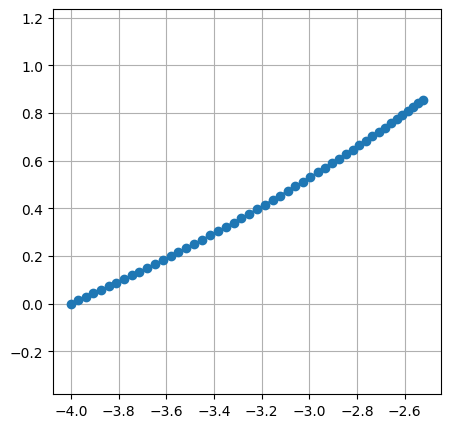

In [25]:
from torchdiffeq import odeint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ODE 右端：只是 UNet 给名义速度，还没加 CBF
def fm_ode_func_local(t, x_flat):
    x_self = x_flat.view(2,)      # (2,)
    t_scalar = float(t.item())    # 比如 t 在 [0, 1]
    with torch.no_grad():
        v_nom = query_local_velocity_from_unet(
            model,
            x_self=x_self,
            t_scalar=t_scalar,
            N_train=100,
            device=device,
        )
    return v_nom.view_as(x_flat)

# 初始点
x0 = torch.tensor([-4.0, 0.0], device=device)

# 时间网格
T_final = 1.0
steps   = 50
T_span  = torch.linspace(0.0, T_final, steps, device=device)

sol = odeint(fm_ode_func_local, x0, T_span)  # (steps, 2)

# 画轨迹
import matplotlib.pyplot as plt
sol_np = sol.detach().cpu().numpy()
plt.figure(figsize=(5,5))
plt.plot(sol_np[:,0], sol_np[:,1], '-o')
plt.axis('equal'); plt.grid(True); plt.show()


In [26]:
import torch

def cbf_project_single_point(
    x_self: torch.Tensor,          # (2,)
    v_nom: torch.Tensor,           # (2,)
    ellipses,
    other_agent_pos: torch.Tensor = None,  # (2,) or None
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 3,
    agent_safe_radius: float = 0.5,
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    单点版 CBF 投影：
      - x_self: 本车当前位置 (2,)
      - v_nom:  FM 给出的名义速度 (2,)
      - ellipses: 椭圆障碍物列表
      - other_agent_pos: 对车当前位置 (2,) 或 None（没有对车）
    """
    device = x_self.device
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_pos is not None

    if (not has_ellipses) and (not has_other):
        return v_nom

    # 先做成 (2,1) 的“伪轨迹”，方便复用 batch 版本的梯度函数
    x_world_2N = x_self.view(2, 1)      # (2,1)
    v_now      = v_nom.view(2, 1)       # (2,1)

    # ------------------------------
    # 1) 压强 P(x) 来自于对车距离
    # ------------------------------
    if has_other:
        delta_agent = (x_self - other_agent_pos).view(1, 2)  # (1,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)  # (1,)
        P = press_k / dist.pow(press_n)                        # (1,)
    else:
        P = torch.zeros(1, device=device)

    gamma_x = gamma_min + w_p * P  # (1,)

    # ------------------------------
    # 2) CBF 投影迭代（小次数）
    # ------------------------------
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (1,2)

        # (a) 静态椭圆障碍
        if has_ellipses:
            for e in ellipses:
                # 这里复用你原来的 ellipse_h_grad_batch
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)  # h: (1,), grad: (1,2)
                h_eff = h_e - float(extra_margin)

                alpha_h = gamma_x * h_eff      # (1,)
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h  # (1,)

                all_s.append(s_e)   # 每个都是 (1,)
                all_a.append(grad_w)  # 每个都是 (1,2)

        # (b) 车车之间的 CBF
        if has_other:
            # h_agent = ||x - x_other||^2 - R^2
            h_agent = dist**2 - agent_safe_radius**2        # (1,)
            grad_agent = 2.0 * delta_agent                  # (1,2)

            alpha_h_agent = gamma_x * h_agent
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            break

        S_cat = torch.cat(all_s, dim=0)     # (E,)
        A_cat = torch.cat(all_a, dim=0)     # (E,2)

        # 找出最危险（s 最小）的那条约束
        s_min, idx_min = torch.min(S_cat, dim=0)   # (), scalar
        a_pick = A_cat[idx_min]                    # (2,)

        if s_min < 0.0:
            a_sq = (a_pick ** 2).sum().clamp_min(1e-12)
            coef = -s_min / a_sq                   # λ = -s / ||a||^2

            delta = coef * a_pick.view(2, 1)       # (2,1)

            if max_corr_norm > 0:
                dnorm = delta.norm().clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta  # (2,1)

    return v_now.view(2,)  # 回到 (2,)


In [27]:
def _fm_ode_func_local(self, t, x_2d_flat):
    """
    ODE 右端：
      dx/dt = CBF(UNet(x,t))
    """
    device = x_2d_flat.device
    x_self = x_2d_flat.view(2,)  # 当前状态

    # 把时间归一化到 [0,1]
    t_scalar = float(t.item())

    # --- Step 1: UNet 给名义速度 ---
    with torch.no_grad():
        v_nom = query_local_velocity_from_unet(
            model=self.model,
            x_self=x_self,
            t_scalar=t_scalar,
            N_train=100,    # 训练用的轨迹长度
            device=device,
        )

    # --- Step 2: 压强 CBF 修正 ---
    v_safe = cbf_project_single_point(
        x_self=x_self, 
        v_nom=v_nom,
        ellipses=self.ellipses,     # 静态障碍
        other_agent_pos=None,       # 先单车
        extra_margin=0.5,
        agent_safe_radius=0.5,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )

    return v_safe.view_as(x_2d_flat)


In [30]:
from torchdiffeq import odeint

def sample_safe_fm_trajectory(
    model,
    start: torch.Tensor,
    ellipses,
    T_final: float = 1.0,
    steps: int = 100,
    N_train: int = 100,
    device: str = "cpu",
):
    """
    用 ODEint 积分生成单车 SafeFlow 轨迹:
        dx/dt = CBF( UNet(x, t) )
    这里是函数形式，不挂在 model 上。
    """
    device = device or start.device
    start = start.to(device).view(2,)   # (2,)

    # --------- 定义 ODE 右端：f(t, x) ---------
    def fm_ode_func_local(t, x_2d_flat):
        x_self = x_2d_flat.view(2,)     # 当前状态 (2,)
        t_scalar = float(t.item())      # 标量时间

        # 1) UNet 给名义速度
        with torch.no_grad():
            v_nom = query_local_velocity_from_unet(
                model=model,
                x_self=x_self,
                t_scalar=t_scalar,
                N_train=N_train,
                device=device,
            )

        # 2) CBF 单点投影（压强版）
        v_safe = cbf_project_single_point(
            x_self=x_self,
            v_nom=v_nom,
            ellipses=ellipses,
            other_agent_pos=None,     # 先单车
            extra_margin=0.5,
            agent_safe_radius=0.5,
            gamma_min=1.0,
            w_p=5.0,
            press_k=1.0,
            press_n=2.0,
        )

        return v_safe.view_as(x_2d_flat)

    # --------- 调用 odeint 积分 ---------
    T_span = torch.linspace(0.0, T_final, steps, device=device)  # (steps,)
    sol = odeint(fm_ode_func_local, start, T_span)               # (steps,2)

    return sol


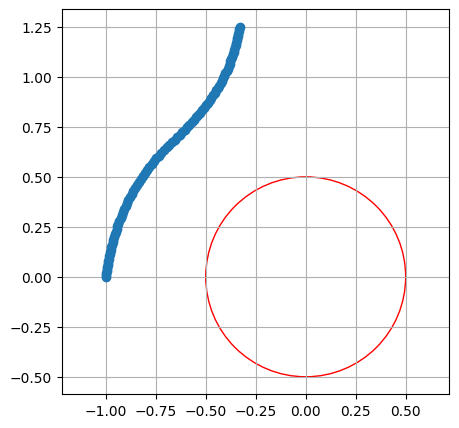

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ellipses = [
    {"center": np.array([0.0, 0.0]), "radius": 0.5},
]

traj = sample_safe_fm_trajectory(
    model,
    start=torch.tensor([-1.0, 0.0], device=device),
    ellipses=ellipses,
    T_final=1.0,
    steps=100,
    N_train=100,
    device=device,
)

traj_np = traj.detach().cpu().numpy()
plt.figure(figsize=(5,5))
plt.plot(traj_np[:,0], traj_np[:,1], '-o')
for e in ellipses:
    circle = plt.Circle(e["center"], e["radius"], edgecolor='r', facecolor='none')
    plt.gca().add_patch(circle)
plt.axis('equal'); plt.grid(True); plt.show()


In [33]:
def _two_car_ode_func(self, t, state_4d):
    """
    状态 state: (4,) = [xA_x, xA_y, xB_x, xB_y]
    返回 dx/dt : (4,)
    """
    device = state_4d.device

    # --- 分拆 A, B 的坐标 ---
    xA = state_4d[0:2]  # (2,)
    xB = state_4d[2:4]  # (2,)

    t_scalar = float(t.item())

    # --- UNet 给名义速度 ---
    with torch.no_grad():
        vA_nom = query_local_velocity_from_unet(
            self.model, xA, t_scalar, N_train=100, device=device
        )
        vB_nom = query_local_velocity_from_unet(
            self.model, xB, t_scalar, N_train=100, device=device
        )

    # --- 压强 CBF 修正（双向） ---
    vA_safe = cbf_project_single_point(
        x_self=xA,
        v_nom=vA_nom,
        ellipses=self.ellipses,
        other_agent_pos=xB,    # 对车
        extra_margin=0.5,
        agent_safe_radius=0.5,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )

    vB_safe = cbf_project_single_point(
        x_self=xB,
        v_nom=vB_nom,
        ellipses=self.ellipses,
        other_agent_pos=xA,    # 对车
        extra_margin=0.5,
        agent_safe_radius=0.5,
        gamma_min=1.0,
        w_p=5.0,
        press_k=1.0,
        press_n=2.0,
    )

    # --- 拼回 (4,) ---
    dxdt = torch.zeros_like(state_4d)
    dxdt[0:2] = vA_safe
    dxdt[2:4] = vB_safe
    return dxdt


In [36]:
def sample_two_car_trajectory(self, start_A, start_B, T_final=1.0, steps=200):
    device = start_A.device

    # 初始 4 维状态
    state0 = torch.tensor([
        start_A[0], start_A[1],
        start_B[0], start_B[1],
    ], dtype=torch.float32, device=device)

    T_span = torch.linspace(0, T_final, steps, device=device)

    sol = odeint(self._two_car_ode_func, state0, T_span)  # (steps,4)

    traj_A = sol[:, 0:2]  # (steps,2)
    traj_B = sol[:, 2:4]  # (steps,2)
    return traj_A, traj_B


In [38]:
from torchdiffeq import odeint

def sample_two_car_trajectory(
    model,
    start_A,
    start_B,
    ellipses,
    T_final: float = 4.0,
    steps: int = 400,
    N_train: int = 100,
    device: str = "cpu",
):
    """
    两车轨迹采样（独立函数版本）：
        state = [xA_x, xA_y, xB_x, xB_y]
        dx/dt = CBF( UNet(x,t) )  双向耦合
    """
    device = device or start_A.device

    start_A = start_A.to(device).view(2,)
    start_B = start_B.to(device).view(2,)

    # 初始 4 维状态
    state0 = torch.tensor(
        [start_A[0], start_A[1], start_B[0], start_B[1]],
        dtype=torch.float32,
        device=device,
    )

    # 时间网格
    T_span = torch.linspace(0.0, T_final, steps, device=device)  # (steps,)

    # --------- 内部定义 ODE 右端：f(t, state) ---------
    def two_car_ode_func(t, state_4d):
        """
        state_4d: (4,) = [xA_x, xA_y, xB_x, xB_y]
        返回 dx/dt: (4,)
        """
        xA = state_4d[0:2]   # (2,)
        xB = state_4d[2:4]   # (2,)

        t_scalar = float(t.item())

        # --- UNet 给名义速度 ---
        with torch.no_grad():
            vA_nom = query_local_velocity_from_unet(
                model=model,
                x_self=xA,
                t_scalar=t_scalar,
                N_train=N_train,
                device=device,
            )
            vB_nom = query_local_velocity_from_unet(
                model=model,
                x_self=xB,
                t_scalar=t_scalar,
                N_train=N_train,
                device=device,
            )

        # --- 压强 CBF 修正（双向） ---
        vA_safe = cbf_project_single_point(
            x_self=xA,
            v_nom=vA_nom,
            ellipses=ellipses,
            other_agent_pos=xB,    # 把 B 当动态障碍
            extra_margin=0.5,
            agent_safe_radius=0.5,
            gamma_min=1.0,
            w_p=5.0,
            press_k=1.0,
            press_n=2.0,
        )

        vB_safe = cbf_project_single_point(
            x_self=xB,
            v_nom=vB_nom,
            ellipses=ellipses,
            other_agent_pos=xA,    # 把 A 当动态障碍
            extra_margin=0.5,
            agent_safe_radius=0.5,
            gamma_min=1.0,
            w_p=5.0,
            press_k=1.0,
            press_n=2.0,
        )

        dxdt = torch.zeros_like(state_4d)
        dxdt[0:2] = vA_safe
        dxdt[2:4] = vB_safe
        return dxdt

    # --------- 调用 odeint ---------
    sol = odeint(two_car_ode_func, state0, T_span)  # (steps,4)

    traj_A = sol[:, 0:2]  # (steps,2)
    traj_B = sol[:, 2:4]  # (steps,2)
    return traj_A, traj_B


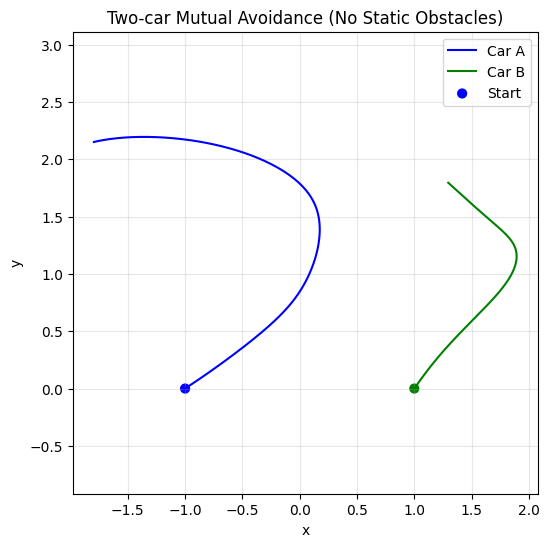

In [42]:
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 1. 不要障碍物
ellipses = []   # 👈 关键：空列表

# 2. 两车起点
start_A = torch.tensor([-1.0, 0.0], dtype=torch.float32, device=device)
start_B = torch.tensor([ 1.0, 0.0], dtype=torch.float32, device=device)

T_final = 4.0
steps   = 400

with torch.no_grad():
    traj_A, traj_B = sample_two_car_trajectory(
        model=model,
        start_A=start_A,
        start_B=start_B,
        ellipses=ellipses,   # 空的，只做两车互相避障
        T_final=T_final,
        steps=steps,
        N_train=100,
        device=device,
    )

# 3. 画图
traj_A_np = traj_A.detach().cpu().numpy()
traj_B_np = traj_B.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
ax = plt.gca()

# 没有障碍物，这里就不画 circle 了

plt.plot(traj_A_np[:, 0], traj_A_np[:, 1], 'b-', label="Car A")
plt.plot(traj_B_np[:, 0], traj_B_np[:, 1], 'g-', label="Car B")

plt.scatter([start_A[0].item(), start_B[0].item()],
            [start_A[1].item(), start_B[1].item()],
            c=['blue', 'green'], marker='o', s=40, label="Start")

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two-car Mutual Avoidance (No Static Obstacles)")
plt.show()


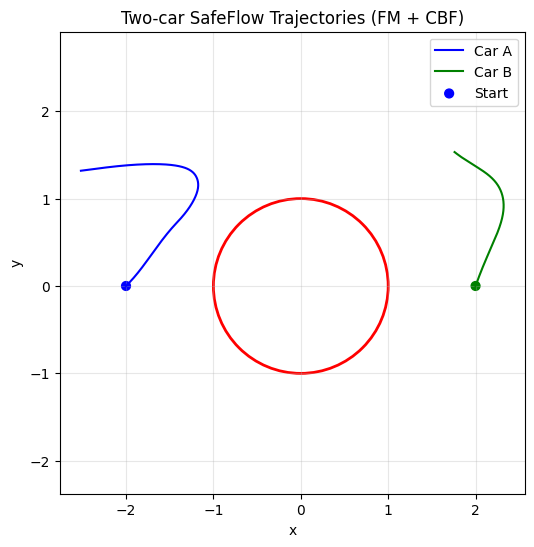

In [40]:
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 1. 定义障碍
ellipses = [
    {"center": np.array([0.0, 0.0]), "radius": 1.0},  # 中间一个圆形障碍
]

# 2. 设置两车起点
start_A = torch.tensor([-2.0, 0.0], dtype=torch.float32, device=device)
start_B = torch.tensor([ 2.0, 0.0], dtype=torch.float32, device=device)

T_final = 4.0
steps   = 400

with torch.no_grad():
    traj_A, traj_B = sample_two_car_trajectory(
        model=model,
        start_A=start_A,
        start_B=start_B,
        ellipses=ellipses,
        T_final=T_final,
        steps=steps,
        N_train=100,
        device=device,
    )

# 3. 画轨迹 + 障碍
traj_A_np = traj_A.detach().cpu().numpy()
traj_B_np = traj_B.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
ax = plt.gca()

# 画障碍
for e in ellipses:
    cx, cy = e["center"]
    r = e["radius"]
    circle = plt.Circle((cx, cy), r, edgecolor="red", facecolor="none", linewidth=2)
    ax.add_patch(circle)

# 画两车轨迹
plt.plot(traj_A_np[:, 0], traj_A_np[:, 1], 'b-', label="Car A")
plt.plot(traj_B_np[:, 0], traj_B_np[:, 1], 'g-', label="Car B")

# 起点标一下
plt.scatter([start_A[0].item(), start_B[0].item()],
            [start_A[1].item(), start_B[1].item()],
            c=['blue', 'green'], marker='o', s=40, label="Start")

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two-car SafeFlow Trajectories (FM + CBF)")
plt.show()


In [47]:
from torchdiffeq import odeint

def sample_two_car_trajectory(
    model,
    start_A,
    start_B,
    goal_A,
    goal_B,
    ellipses,
    T_final: float = 4.0,
    steps: int = 400,
    N_train: int = 100,
    k_goal: float = 3.0,      # 追 goal 的力度
    device: str = "cpu",
):
    """
    两车轨迹采样（独立函数版本 + 目标点）：
        state = [xA_x, xA_y, xB_x, xB_y]
        dx/dt = CBF( UNet(x,t) + v_goal(x, goal) )
    """
    device = device or start_A.device

    start_A = start_A.to(device).view(2,)
    start_B = start_B.to(device).view(2,)
    goal_A  = goal_A.to(device).view(2,)
    goal_B  = goal_B.to(device).view(2,)

    # 初始 4 维状态
    state0 = torch.tensor(
        [start_A[0], start_A[1], start_B[0], start_B[1]],
        dtype=torch.float32,
        device=device,
    )

    # 时间网格
    T_span = torch.linspace(0.0, T_final, steps, device=device)  # (steps,)

    def two_car_ode_func(t, state_4d):
        """
        state_4d: (4,) = [xA_x, xA_y, xB_x, xB_y]
        返回 dx/dt: (4,)
        """
        xA = state_4d[0:2]   # (2,)
        xB = state_4d[2:4]   # (2,)

        t_scalar = float(t.item())

        # --- UNet 给名义速度 ---
        with torch.no_grad():
            vA_fm = query_local_velocity_from_unet(
                model=model,
                x_self=xA,
                t_scalar=t_scalar,
                N_train=N_train,
                device=device,
            )
            vB_fm = query_local_velocity_from_unet(
                model=model,
                x_self=xB,
                t_scalar=t_scalar,
                N_train=N_train,
                device=device,
            )

        # --- 朝各自 goal 的吸引速度（单位方向 * k_goal）---
        def goal_vel(x, g):
            d = g - x
            dist = torch.norm(d).clamp_min(1e-3)
            return k_goal * d / dist

        vA_goal = goal_vel(xA, goal_A)
        vB_goal = goal_vel(xB, goal_B)

        # FM + goal 合成名义速度
        vA_nom = vA_fm + vA_goal
        vB_nom = vB_fm + vB_goal

        # --- 压强 CBF 修正（双向），压强变弱 ---
        vA_safe = cbf_project_single_point(
            x_self=xA,
            v_nom=vA_nom,
            ellipses=ellipses,
            other_agent_pos=xB,    # 把 B 当动态障碍
            extra_margin=0.5,
            agent_safe_radius=0.5,
            gamma_min=1.0,
            w_p=2.0,        # 之前是 5.0 → 压强整体弱一些
            press_k=0.5,     # 之前是 1.0 → 距离相关项也弱一点
            press_n=2.0,
        )

        vB_safe = cbf_project_single_point(
            x_self=xB,
            v_nom=vB_nom,
            ellipses=ellipses,
            other_agent_pos=xA,    # 把 A 当动态障碍
            extra_margin=0.5,
            agent_safe_radius=0.5,
            gamma_min=1.0,
            w_p=2.0,
            press_k=0.5,
            press_n=2.0,
        )

        dxdt = torch.zeros_like(state_4d)
        dxdt[0:2] = vA_safe
        dxdt[2:4] = vB_safe
        return dxdt

    sol = odeint(two_car_ode_func, state0, T_span)  # (steps,4)

    traj_A = sol[:, 0:2]  # (steps,2)
    traj_B = sol[:, 2:4]  # (steps,2)
    return traj_A, traj_B


In [51]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 1. 不要障碍物
ellipses = []   # 👈 只开车车互相避障

# 2. 起点 & 终点
start_A = torch.tensor([-1.0, 0.0], dtype=torch.float32, device=device)
goal_A  = torch.tensor([ 1.0, 0.0], dtype=torch.float32, device=device)

start_B = torch.tensor([ 1.0, 0.0], dtype=torch.float32, device=device)
goal_B  = torch.tensor([-1.0, 0.0], dtype=torch.float32, device=device)

T_final = 3.0
steps   = 300

with torch.no_grad():
    traj_A, traj_B = sample_two_car_trajectory(
        model=model,
        start_A=start_A,
        start_B=start_B,
        goal_A=goal_A,
        goal_B=goal_B,
        ellipses=ellipses,   # 空列表
        T_final=T_final,
        steps=steps,
        N_train=100,
        k_goal=5.0,          # 追目标的力度，可以之后再调
        device=device,
    )

traj_A_np = traj_A.detach().cpu().numpy()
traj_B_np = traj_B.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
ax = plt.gca()

# 画两车轨迹
plt.plot(traj_A_np[:, 0], traj_A_np[:, 1], 'b-', label="Car A")
plt.plot(traj_B_np[:, 0], traj_B_np[:, 1], 'g-', label="Car B")

# 起点 & 终点
plt.scatter([start_A[0].item(), start_B[0].item()],
            [start_A[1].item(), start_B[1].item()],
            c=['blue', 'green'], marker='o', s=40, label="Start")

plt.scatter([goal_A[0].item(), goal_B[0].item()],
            [goal_A[1].item(), goal_B[1].item()],
            c=['blue', 'green'], marker='x', s=60, label="Goal")

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two-car Mutual Avoidance with Goals (Weak Pressure Field)")
plt.show()


KeyboardInterrupt: 